In [1]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, RR3short_gate
from sim_library.sequences2 import RR3short_gate as RR3short_gate2
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
N = 50
Temp = 1e-6

cycles = 8

rabi_freq = 2*pi*0.5e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3short_gate2(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[20] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)


moms_list, fracs_list, _ = simulate_alg_cooling_custom(basis=basis, sequence=RR3, time_steps=time_steps, n_atoms=N, temp=Temp, initial_state=initial_state, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3', save_dir='data/algorithmic cooling')

In [14]:
path = Path("data/algorithmic cooling/2026-03-18_algcooling_f3_8cycles_1muK_50atoms_5e+05Hz_2.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

moms_list = [mom / (hbar * k_eff) for mom in moms_list]

In [9]:
print(Temp)

5e-05


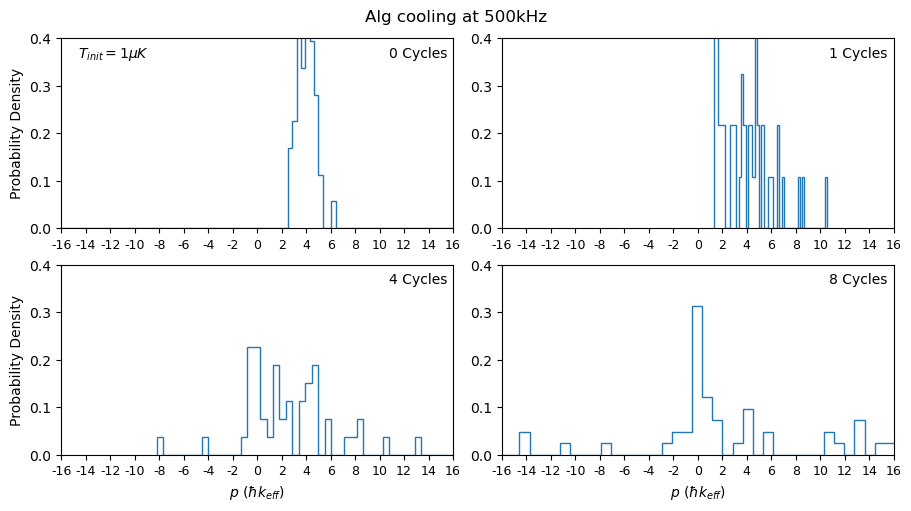

In [15]:


cycles_list = np.array([0,1,4,8])
index_list = np.array([0,2,8,16])
bins_list = np.full(4, 50)
bins_list[0] = 100

plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, title='Alg cooling at 500kHz', ylims=0.4, temp=Temp, show=False,
                    #    save_dir="plots/histograms/algorithmic cooling/2026-03-18_algcooling_f3_8cycles_15muK_5000atoms_5e+05Hz.png"
                       )

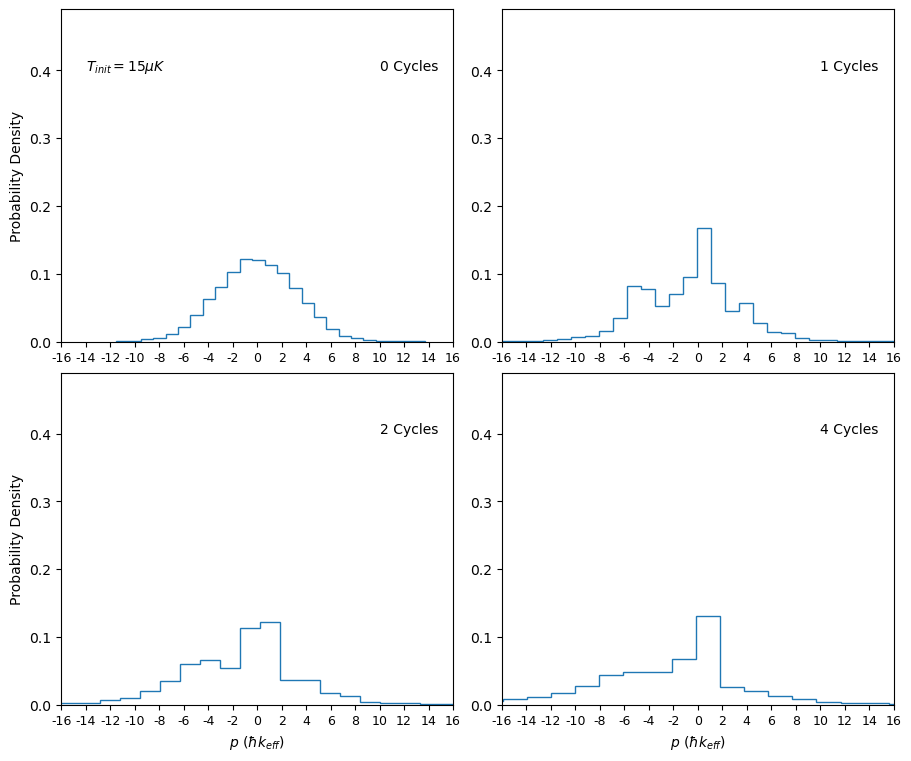

In [14]:
fig1, axes = plt.subplots(2,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 50

index_list = [0,1,3,7]


axes[0].hist(x= moms_list[0], bins = 25, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.49)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,4):
    axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i]], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.49)


axes[2].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[3].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()


ValueError: weights should have the same shape as x

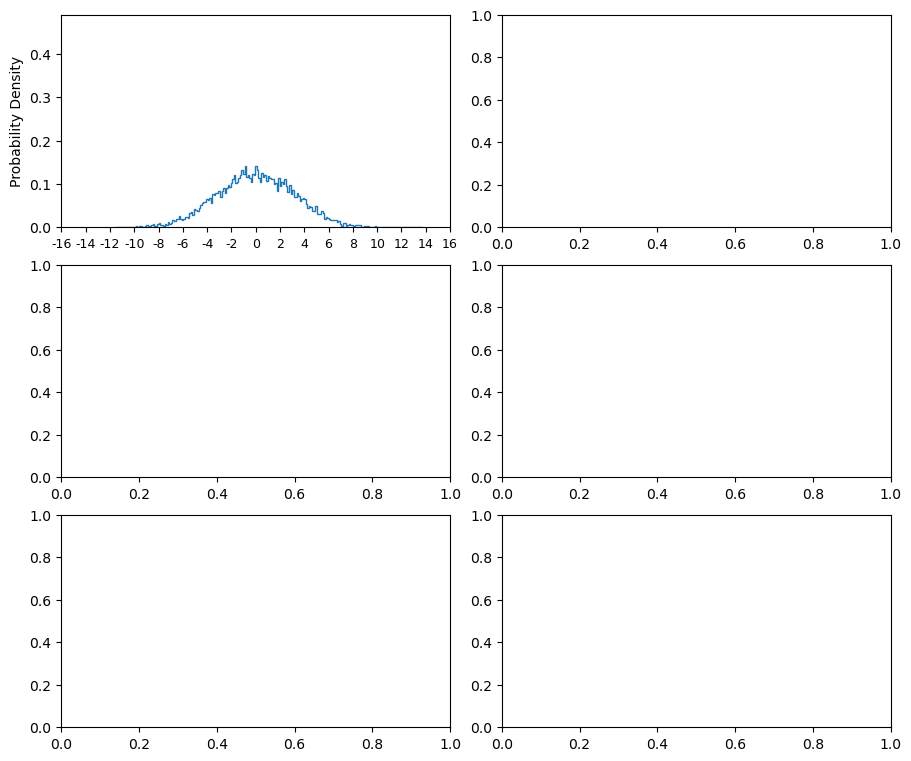

In [15]:

fig1, axes = plt.subplots(3,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 400

index_list = [0,1,3,5,7]

axes[0].hist(x= moms_list[0], bins = 200, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.49)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,6):
    axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i-1]], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.49)


axes[4].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[5].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')
axes[4].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')
axes[4].text(10,0.4,r'6 Cycles')
axes[5].text(10,0.4,r'8 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()


In [14]:
moms_list = [0,2,1]
fracs_list = moms_list

In [17]:
p_min = 0
p_max = 4
basis = np.arange(p_min, p_max + 1)

rng = np.random.default_rng()
rng_state = dict(rng.bit_generator.state)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 1
initial_state[3] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

sigma = np.sqrt(kb*Temp/m)
p_dist = m*rng.normal(loc = 0, scale = sigma, size = N)

init_mom_dist_tiled = np.tile(p_dist, (len(basis),1))

basis_tiled = np.transpose(np.tile(basis, (N,1)))

mom_dist_grid = init_mom_dist_tiled + (hbar*k_eff*basis_tiled)
p_dist_absolute = np.ravel(mom_dist_grid) 

square = np.abs(initial_state)**2
state_fractions = np.tile(square[:, np.newaxis], (1, N))
state_fractions = state_fractions.ravel()

print(p_dist_absolute/(hbar*k_eff))
print(state_fractions)

[-2.17206671  7.98864591 -3.0205213  -5.13859045 -0.3966583  -1.17206671
  8.98864591 -2.0205213  -4.13859045  0.6033417  -0.17206671  9.98864591
 -1.0205213  -3.13859045  1.6033417   0.82793329 10.98864591 -0.0205213
 -2.13859045  2.6033417   1.82793329 11.98864591  0.9794787  -1.13859045
  3.6033417 ]
[0.5 0.5 0.5 0.5 0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.5 0.5
 0.5 0.5 0.  0.  0.  0.  0. ]
